In [1]:
# !pip install transformers
# !pip install jiwer
# !pip install torch
# !pip install Pillow
# !pip install kagglehub
# !pip install IPython
# !pip install scikit-learn
# !pip install pandas
# !pip install tqdm
# !pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install torchvision
# !pip install openpyxl


In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"GPU count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU name: NVIDIA GeForce RTX 5060 Ti


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from torchvision import transforms
from PIL import Image
import requests
import kagglehub
from IPython.display import display
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tqdm import tqdm
from jiwer import cer, wer
import torch.nn.utils.rnn as rnn_utils
from transformers import get_linear_schedule_with_warmup
import logging
import csv
from datetime import datetime

# Датасет из каггла

In [4]:
path = kagglehub.dataset_download("constantinwerner/cyrillic-handwriting-dataset")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\maill\.cache\kagglehub\datasets\constantinwerner\cyrillic-handwriting-dataset\versions\5


# Посмотрим картинки

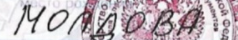

In [5]:
img_path = 'C:\\Users\\maill\\.cache\\kagglehub\\datasets\\constantinwerner\\cyrillic-handwriting-dataset\\versions\\5\\train\\aa1.png'
image = Image.open(img_path).convert('RGB')
display(image)

# Подготавливаем данные

In [6]:
def load_tsv(tsv_path, base_path):
    df = pd.read_csv(tsv_path, sep='\t', header=None, names=['image', 'text'])

    images = []
    texts = []

    for _, row in df.iterrows():
        img_path = row['image']
        text = row['text']

        if not isinstance(text, str):
            print(f"Пропущено (не строка): {img_path} -> {text}")
            continue

        text = text.strip()
        if len(text) == 0:
            print(f" Пропущено (пустая строка): {img_path}")
            continue

        if not os.path.isabs(img_path):
            img_path = os.path.join(base_path, img_path)

        if not os.path.exists(img_path):
            print(f"Пропущено (нет файла): {img_path}")
            continue

        images.append(img_path)
        texts.append(text)

    print(f"Загружено пар: {len(images)} (пропущено: {len(df) - len(images)})")
    return images, texts

In [7]:
path = path
IMAGE_BASE_PATH = os.path.join(path, 'train')
train_tsv = os.path.join(path, 'train.tsv')
test_tsv = os.path.join(path, 'test.tsv')

train_imgs, train_texts = load_tsv(train_tsv, IMAGE_BASE_PATH)
test_imgs, test_texts = load_tsv(test_tsv, os.path.join(path, 'test'))

train_imgs, val_imgs, train_txts, val_txts = train_test_split(train_imgs, train_texts, test_size=0.15, random_state=42)

Пропущено (не строка): yob3873.png -> nan
Пропущено (не строка): yob4721.png -> nan
Загружено пар: 72284 (пропущено: 2)
Загружено пар: 1544 (пропущено: 0)


In [8]:
class HandwrittenDataset(Dataset):
    def __init__(self, image_paths, texts, processor, augment=False):
        self.image_paths = image_paths
        self.texts = texts
        self.processor = processor

        assert len(image_paths) == len(texts), "Длины списков не совпадают!"

        if augment:
            self.augmentation = transforms.Compose([
                transforms.RandomRotation(degrees=2),
                transforms.RandomAffine(degrees=0, translate=(0.02, 0.02)),
                transforms.ColorJitter(brightness=0.2, contrast=0.2),
            ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        text = self.texts[idx]

        if not isinstance(text, str):
            raise TypeError(f"Текст должен быть str, а получил {type(text)} на индексе {idx}: {text}")

        try:
            img = Image.open(img_path).convert('RGB')
            pixel_values = self.processor(images=img, return_tensors='pt').pixel_values
            labels = self.processor(text=text, return_tensors='pt').input_ids
            return {'pixel_values': pixel_values, 'labels': labels}
        except Exception as e:
            print(f"\n Ошибка на индексе {idx}: {img_path} | Текст: {text}")
            print(f"Ошибка: {e}")
            raise

def collate_fn(batch):
    pixel_values = torch.cat([item['pixel_values'] for item in batch], dim=0)
    labels = [item['labels'].squeeze(0) for item in batch]
   
    # processor доступен глобально (определен в ячейке [10])
    labels_padded = rnn_utils.pad_sequence(
        labels,
        batch_first=True,
        padding_value=processor.tokenizer.pad_token_id
    )
   
    return {'pixel_values': pixel_values, 'labels': labels_padded}

## Подготовка данных заказчика

In [9]:
excel_path = 'C:/Users/maill/WORK/Dataset/32_14.xlsx'
base_images_path = 'C:/Users/maill/WORK/Dataset'

In [10]:
def get_full_image_path(image_path):
    return os.path.join(base_images_path, image_path)

In [11]:
df = pd.read_excel(excel_path)

df = df[df['label'].notna()]
df = df[df['label'].astype(str).str.strip() != '']

# df['image_path'] = base_images_path + '/' + df['image_path']
df['full_path'] = df['image_path'].apply(lambda x: base_images_path + '/' + x + '.jpg')
df['full_path'] = df['full_path'].apply(lambda x: os.path.join(x.replace('\\', '/')) if pd.notna(x) else x)


In [12]:
df

,Unnamed: 0,image_path,label,full_path
0,0,32_14/img_1,В,C:/Users/maill/WORK/Dataset/32_14/img_1.jpg
1,1,32_14/img_2,Редкцию,C:/Users/maill/WORK/Dataset/32_14/img_2.jpg
2,2,32_14/img_3,областной,C:/Users/maill/WORK/Dataset/32_14/img_3.jpg
3,3,32_14/img_4,газеты,C:/Users/maill/WORK/Dataset/32_14/img_4.jpg
4,4,32_14/img_5,Хорошо,C:/Users/maill/WORK/Dataset/32_14/img_5.jpg
...,...,...,...,...
56,56,32_14/img_58,района,C:/Users/maill/WORK/Dataset/32_14/img_58.jpg
57,57,32_14/img_59,Ирбитского,C:/Users/maill/WORK/Dataset/32_14/img_59.jpg
58,58,32_14/img_60,округа,C:/Users/maill/WORK/Dataset/32_14/img_60.jpg
59,59,32_14/img_61,Фоминцов,C:/Users/maill/WORK/Dataset/32_14/img_61.jpg


In [13]:
df['exists'] = df['full_path'].apply(os.path.exists)
df = df[df['exists']].reset_index(drop=True)

In [14]:
class CustomerTestDataset(Dataset):
        def __init__(self, df, processor):
            self.df = df
            self.processor = processor
        
        def __len__(self):
            return len(self.df)
        
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            img = Image.open(row['full_path']).convert('RGB')
            pixel_values = self.processor(images=img, return_tensors='pt').pixel_values[0]
            return {
                'pixel_values': pixel_values,
                'true_text': str(row['label']),
                'image_path': row['image_path']
            }

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [16]:
processor = TrOCRProcessor.from_pretrained("./best_model_customer")
model = VisionEncoderDecoderModel.from_pretrained("./best_model_customer")

model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

In [17]:
model.to(device)

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.05, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.05, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            

In [18]:
train_dataset = HandwrittenDataset(train_imgs, train_txts, processor, augment=False)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

val_dataset = HandwrittenDataset(val_imgs, val_txts, processor)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

# Данные заказчика
test_dataset = CustomerTestDataset(df, processor)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [19]:
def clear_cuda_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        print(f"GPU Memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

## Обучаем

In [20]:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
EPOCHS = 3
accumulation_steps = 4

num_training_steps = len(train_loader) * EPOCHS // accumulation_steps
num_warmup_steps = int(0.1 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [21]:
os.makedirs("./training_logs", exist_ok=True)

In [22]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("./training_logs/training_kaggle.log", encoding='utf-8'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

In [23]:
logger.info("="*60)
logger.info("НАЧАЛО ОБУЧЕНИЯ НА KAGGLE ДАТАСЕТЕ")
logger.info("="*60)
logger.info(f"Train samples: {len(train_dataset)}")
logger.info(f"Val samples: {len(val_dataset)}")
logger.info(f"Batch size: 4")
logger.info(f"Epochs: {EPOCHS}")
logger.info(f"Learning rate: 5e-5")
logger.info(f"Accumulation steps: {accumulation_steps}")
logger.info(f"Device: {device}")

2026-05-20 19:39:26,298 - INFO - ============================================================
2026-05-20 19:39:26,299 - INFO - НАЧАЛО ОБУЧЕНИЯ НА KAGGLE ДАТАСЕТЕ
2026-05-20 19:39:26,300 - INFO - ============================================================
2026-05-20 19:39:26,300 - INFO - Train samples: 61441
2026-05-20 19:39:26,301 - INFO - Val samples: 10843
2026-05-20 19:39:26,302 - INFO - Batch size: 4
2026-05-20 19:39:26,302 - INFO - Epochs: 3
2026-05-20 19:39:26,303 - INFO - Learning rate: 5e-5
2026-05-20 19:39:26,303 - INFO - Accumulation steps: 4
2026-05-20 19:39:26,304 - INFO - Device: cuda


In [24]:
metrics_log = []
csv_filename = "./training_logs/metrics_kaggle.csv"

In [26]:
best_val_loss = float('inf')
best_val_cer = float('inf')

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss_total = 0
    optimizer.zero_grad()
    
    with tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]") as pbar:
        for i, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)
            
            outputs = model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / accumulation_steps
            loss.backward()
            
            train_loss_total += outputs.loss.item() / accumulation_steps  
            
            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            
            pbar.set_postfix({'loss': f'{outputs.loss.item():.4f}'})
            
            del pixel_values, labels, outputs, loss
    
    avg_train_loss = train_loss_total / len(train_loader)
    
    # Validation
    model.eval()
    val_loss_total = 0
    val_cer_scores = []
    
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]") as pbar:
            for batch in pbar:
                pixel_values = batch['pixel_values'].to(device, non_blocking=True)
                labels = batch['labels'].to(device, non_blocking=True)
                
                outputs = model(pixel_values=pixel_values, labels=labels)
                val_loss_total += outputs.loss.item()
                
                generated_ids = model.generate(
                    pixel_values, 
                    max_length=32,
                    num_beams=2,  
                    early_stopping=True
                )
                
                pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)
                true_texts = processor.batch_decode(labels, skip_special_tokens=True)
                
                batch_cer = [cer(true, pred) for pred, true in zip(pred_texts, true_texts)]
                val_cer_scores.extend(batch_cer)
                
                pbar.set_postfix({
                    'val_loss': f'{outputs.loss.item():.4f}',  
                    'val_CER': f'{sum(batch_cer)/len(batch_cer):.4f}'
                })
                
                del pixel_values, labels, outputs, generated_ids
    

    avg_val_loss = val_loss_total / len(val_loader)
    avg_val_cer = sum(val_cer_scores) / len(val_cer_scores) if val_cer_scores else 0
    current_lr = scheduler.get_last_lr()[0]

    logger.info(f"Epoch {epoch+1}/{EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val CER={avg_val_cer:.4f}, LR={current_lr:.2e}")
    metrics_log.append({...})
    
    print(f"Epoch {epoch+1}/{EPOCHS}: LR={current_lr:.2e}, Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val CER={avg_val_cer:.4f}")
    
    # Save best model by CER (более показательно) или по loss
    if avg_val_cer < best_val_cer:
        best_val_cer = avg_val_cer
        best_val_loss = avg_val_loss
        model.save_pretrained("./best_model_kaggle")
        processor.save_pretrained("./best_model_kaggle")
        logger.info(f"Сохранена лучшая модель (CER={avg_val_cer:.4f})")
    
    # Очищать кэш не каждый раз
    if epoch % 5 == 0:
        torch.cuda.empty_cache()

torch.cuda.empty_cache()
logger.info(f"Обучение завершено. Лучший Val CER: {best_val_cer:.4f}")

Epoch 1 [Val]: 100%|██████████| 2711/2711 [29:33<00:00,  1.53it/s, val_loss=0.6597, val_CER=0.1333]
2026-05-20 22:55:26,518 - INFO - Epoch 1/3: Train Loss=0.0252, Val Loss=0.0814, Val CER=0.0549, LR=1.85e-05


Epoch 1/3: LR=1.85e-05, Train Loss=0.0252, Val Loss=0.0814, Val CER=0.0549


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-20 22:55:27,772 - INFO - Сохранена лучшая модель (CER=0.0549)
Epoch 2 [Val]: 100%|██████████| 2711/2711 [29:38<00:00,  1.52it/s, val_loss=0.2004, val_CER=0.1414]
2026-05-21 00:33:59,578 - INFO - Epoch 2/3: Train Loss=0.0114, Val Loss=0.0639, Val CER=0.0428, LR=0.00e+00


Epoch 2/3: LR=0.00e+00, Train Loss=0.0114, Val Loss=0.0639, Val CER=0.0428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-21 00:34:00,962 - INFO - Сохранена лучшая модель (CER=0.0428)
Epoch 3 [Val]: 100%|██████████| 2711/2711 [30:21<00:00,  1.49it/s, val_loss=0.0075, val_CER=0.0000]
2026-05-21 02:13:17,941 - INFO - Epoch 3/3: Train Loss=0.0057, Val Loss=0.0634, Val CER=0.0428, LR=0.00e+00


Epoch 3/3: LR=0.00e+00, Train Loss=0.0057, Val Loss=0.0634, Val CER=0.0428


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

2026-05-21 02:13:19,321 - INFO - Сохранена лучшая модель (CER=0.0428)
2026-05-21 02:13:19,353 - INFO - Обучение завершено. Лучший Val CER: 0.0428


In [27]:
model = VisionEncoderDecoderModel.from_pretrained("./best_model_checkpoint")
model.to(device)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

In [29]:
model.eval()

results = []

with tqdm(test_loader, desc="Testing") as pbar:
    with torch.no_grad():
        for batch in pbar:
            pixel_values = batch['pixel_values'].to(device)
            true_texts = batch['true_text']
            image_paths = batch['image_path']

            generated_ids = model.generate(
                pixel_values, 
                max_length=64, 
                num_beams=2,
                early_stopping=True
            )

            pred_texts = processor.batch_decode(generated_ids, skip_special_tokens=True)

            for img_path, true, pred in zip(image_paths, true_texts, pred_texts):
                results.append({
                    'image_path': img_path,
                    'true_label': true,
                    'predicted': pred,
                    'cer': cer(true, pred),
                    'wer': wer(true, pred)
                })

df_results = pd.DataFrame(results)
df_results.to_csv('customer_test_results.csv', index=False)

print('РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ')
print(f'Всего образцов: {len(df_results)}')
print(f"Средний CER: {df_results['cer'].mean()}")
print(f"Минимальный CER: {df_results['cer'].min()}")
print(f"Максимальный CER: {df_results['cer'].max()}")
print(f"Средний WER: {df_results['wer'].mean()}")
print(f"Минимальный WER: {df_results['wer'].min()}")
print(f"Максимальный WER: {df_results['wer'].max()}")

Testing: 100%|██████████| 8/8 [00:07<00:00,  1.05it/s]

РЕЗУЛЬТАТЫ ТЕСТИРОВАНИЯ
Всего образцов: 61
Средний CER: 0.20538937383199676
Минимальный CER: 0.0
Максимальный CER: 2.0
Средний WER: 0.44535519125683054
Минимальный WER: 0.0
Максимальный WER: 1.0
